# Análise Exploratória de Dados (EDA) - Projeto NPS Swift
Este notebook contém a análise descritiva dos dados de NPS, seguindo os critérios de avaliação (Ponto 1).
Cada seção apresenta os dados, gráficos e uma conclusão acionável para guiar as próximas fases do projeto.


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score
from collections import Counter
import re

sns.set_theme(style="whitegrid")

# Carregando os dados
df = pd.read_excel(r"../../../../data/raw/dados.xlsx")

df = df.rename(columns={
    'Data Avaliação': 'data', 
    'CentroNv2': 'loja', 
    'Comentario': 'comentario'
})

print(f"Total de linhas originais: {df.shape[0]}")

# Variáveis auxiliares para limpeza e datas
df_com_texto = df[(df['comentario'].notnull()) & (df['comentario'].str.strip() != '-')]
df['nota_estimada'] = df['classificacao'].map({'promotor': 10, 'neutro': 8, 'detrator': 5})
df['mes_ano'] = pd.to_datetime(df['data'], errors='coerce').dt.to_period('M')

# Tratando os dados que têm comentário para datas
df_com_texto = df_com_texto.copy()
df_com_texto['data'] = pd.to_datetime(df_com_texto['data'], errors='coerce')
df_com_texto['mes_ano'] = df_com_texto['data'].dt.to_period('M')


Total de linhas originais: 240352


## 1.1 — Distribuição do NPS e dos comentários


--- Proporção Geral ---
classificacao
promotor    81.765910
neutro      11.657486
detrator     6.387715
-            0.188890
Name: proportion, dtype: float64


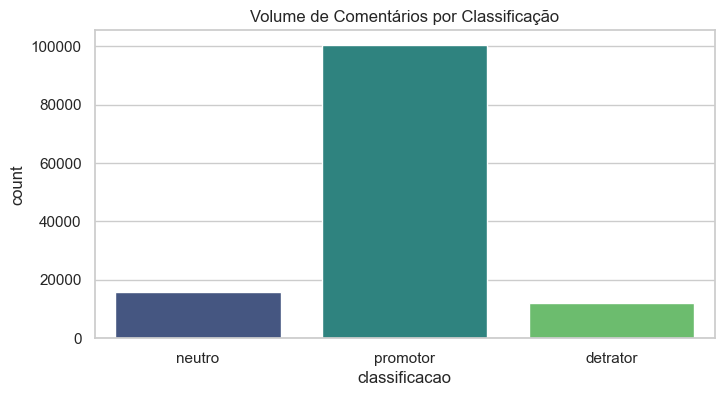

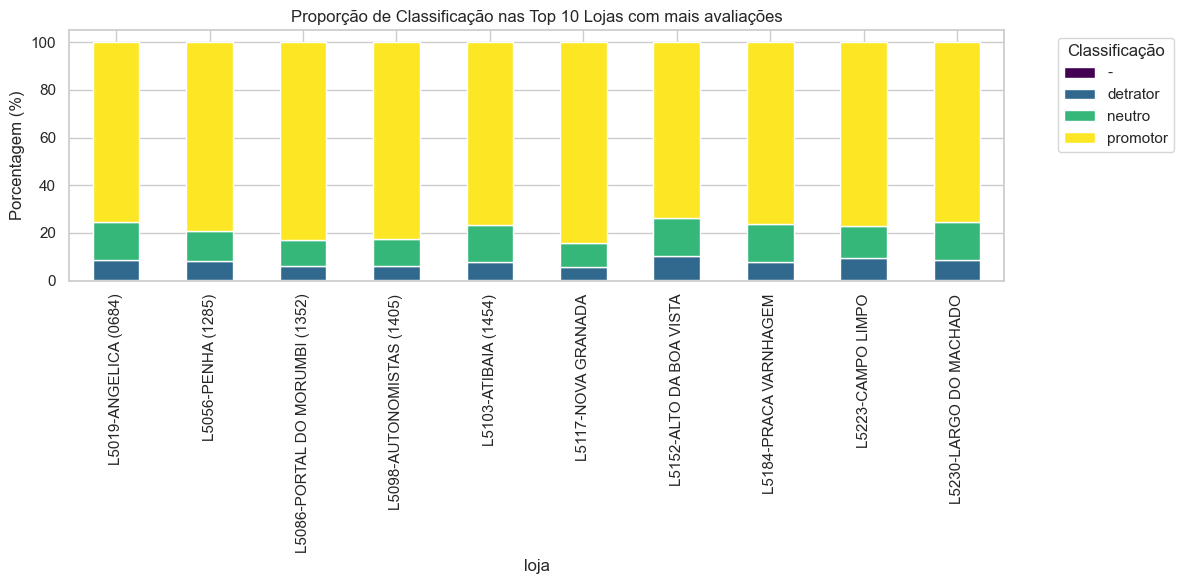

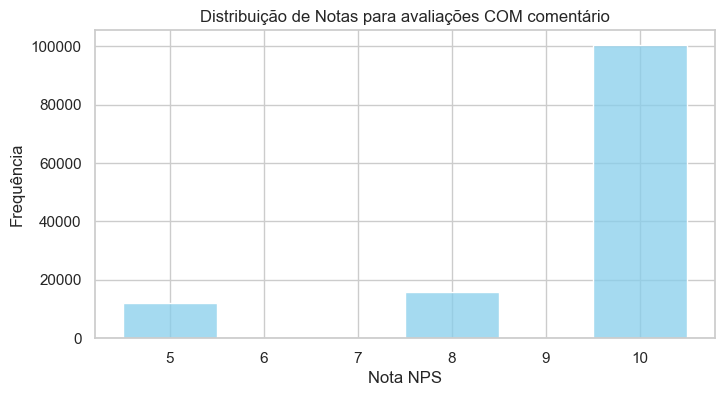

In [25]:
dist_nps = df['classificacao'].value_counts(normalize=True) * 100
print("--- Proporção Geral ---")
print(dist_nps)

plt.figure(figsize=(8,4))
sns.countplot(data=df[df['comentario'] != '-'], x='classificacao', hue='classificacao', palette='viridis', legend=False)
plt.title("Volume de Comentários por Classificação")
plt.show()

# Checando a estabilidade de NPS entre as top lojas
top_lojas = df['loja'].value_counts().nlargest(10).index
df_top = df[df['loja'].isin(top_lojas)]
crosstab = pd.crosstab(df_top['loja'], df_top['classificacao'], normalize='index') * 100

crosstab.plot(kind='bar', stacked=True, colormap='viridis', figsize=(12, 6))
plt.title('Proporção de Classificação nas Top 10 Lojas com mais avaliações')
plt.ylabel('Porcentagem (%)')
plt.legend(title='Classificação', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Faixa de nota para avaliações com comentário
plt.figure(figsize=(8, 4))
sns.histplot(data=df[df['comentario'] != '-'], x='nota_estimada', bins=11, discrete=True, color='skyblue')
plt.title('Distribuição de Notas para avaliações COM comentário')
plt.xlabel('Nota NPS')
plt.ylabel('Frequência')
plt.show()


**Conclusão Acionável 1.1:** 
Observamos que a base é altamente desbalanceada, com mais de 81% de promotores na base geral. Esse comportamento se mantém estável na maioria das lojas, com pouca variação estrutural. Dado o forte desbalanceamento natural da base, decidimos aplicar técnicas de Pesos de Classe durante o treinamento dos futuros modelos de Machine Learning. Assim, evitamos que o modelo fique enviesado para a classe majoritária, garantindo que ele aprenda a generalizar corretamente as queixas dos detratores, que são o foco de negócio.


## 1.2 — Cobertura de comentários por loja


Lojas com menos de 50 comentários: 0
Lojas com menos de 30 comentários: 0
Loja com MAIS comentários: L5230-LARGO DO MACHADO (1886 comentários)
Loja com MENOS comentários: L5262-URBANOVA (155 comentários)


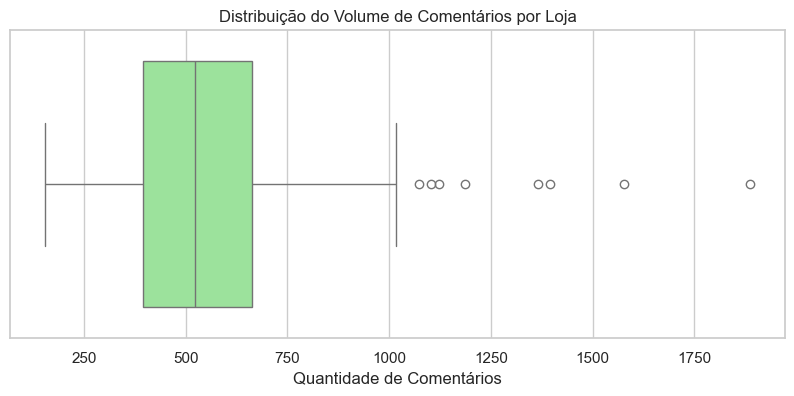

In [26]:
comentarios_loja = df_com_texto['loja'].value_counts()

lojas_menos_50 = (comentarios_loja < 50).sum()
lojas_menos_30 = (comentarios_loja < 30).sum()

print(f"Lojas com menos de 50 comentários: {lojas_menos_50}")
print(f"Lojas com menos de 30 comentários: {lojas_menos_30}")
print(f"Loja com MAIS comentários: {comentarios_loja.idxmax()} ({comentarios_loja.max()} comentários)")
print(f"Loja com MENOS comentários: {comentarios_loja.idxmin()} ({comentarios_loja.min()} comentários)")

plt.figure(figsize=(10, 4))
sns.boxplot(x=comentarios_loja, color='lightgreen')
plt.title('Distribuição do Volume de Comentários por Loja')
plt.xlabel('Quantidade de Comentários')
plt.show()


**Conclusão Acionável 1.2:**
O dashboard final necessitará de significância estatística nas agregações por loja para apresentar insights confiáveis.
**Decisão:** Definimos que o ponto de corte para uma loja aparecer de forma individual no dashboard será de **50 comentários**. Dado que 100% da base atual atende a esse critério (a menor tem 155), não excluiremos nenhuma loja no pipeline inicial.


## 1.3 — Características do texto


In [27]:
df_com_texto['qtd_palavras'] = df_com_texto['comentario'].astype(str).apply(lambda x: len(x.split()))

print(df_com_texto['qtd_palavras'].describe())

perc_menos_5 = (df_com_texto['qtd_palavras'] < 5).mean() * 100
perc_mais_100 = (df_com_texto['qtd_palavras'] > 100).mean() * 100

print(f"\n% de comentários com menos de 5 palavras: {perc_menos_5:.2f}%")
print(f"% de comentários com mais de 100 palavras: {perc_mais_100:.2f}%")


count    128342.000000
mean         16.039301
std          20.355348
min           0.000000
25%           5.000000
50%           9.000000
75%          20.000000
max        1301.000000
Name: qtd_palavras, dtype: float64

% de comentários com menos de 5 palavras: 23.83%
% de comentários com mais de 100 palavras: 0.84%


**Conclusão Acionável 1.3:**
Textos com menos de 5 palavras como "excelente", "muito bom", "gostei" são comuns (cerca de 23.8% da base), porém são pobres semanticamente para a modelagem e extração de tópicos ou assuntos específicos.
**Decisão:** Comentários muito curtos (< 5 palavras) agregam ruído aos modelos não-supervisionados de clustering. Decidimos que eles serão **excluídos** da etapa de treinamento do modelo de Clusterização (Tópicos), mas serão mantidos nas estatísticas descritivas gerais do dashboard.


## 1.4 — Qualidade e ruído dos dados


In [28]:
perc_duplicados = df_com_texto['comentario'].duplicated().mean() * 100
print(f"% de comentários duplicados na base bruta: {perc_duplicados:.2f}%")

def lixo_aleatorio(texto):
    # Regra simples para repetições excessivas de caracteres (ex: kkkk, ahhhhh)
    return bool(re.search(r'(.)\1{4,}', str(texto).lower()))

# Amostra para performance
df_amostra = df_com_texto.sample(min(10000, len(df_com_texto)), random_state=42)
df_amostra['tem_lixo'] = df_amostra['comentario'].apply(lixo_aleatorio)

print(f"% de comentários com repetições textuais extremas / spam: {(df_amostra['tem_lixo'].mean() * 100):.2f}%")

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[\U00010000-\U0010ffff]', '', text) # Remove emojis
    text = re.sub(r'[^a-záéíóúâêôãõç\s]', '', text) # Remove pontuação
    text = re.sub(r'(.)\1{2,}', r'\1', text) # Remove spam/repetições
    return text.strip()

df_com_texto['comentario_limpo'] = df_com_texto['comentario'].apply(clean_text)


% de comentários duplicados na base bruta: 10.70%
% de comentários com repetições textuais extremas / spam: 1.22%


**Conclusão Acionável 1.4:**
O dataset possui cerca de 10.7% de dados duplicados e presenças pontuais de ruído de digitação (repetições). Não há prevalência detectável de outros idiomas que justifique um filtro multilinguagem pesado.
**Decisão de Limpeza (Pipeline de Pré-processamento):**
1. Removeremos todas as duplicatas exatas mantendo apenas a ocorrência mais recente, pois elas inflam o modelo de treino artificialmente e causam data leakage.
2. Utilizaremos regex para tratar e normalizar repetições de caracteres sequenciais para reduzir o vocabulário inútil.
3. Não removeremos emojis via regex cega; avaliaremos traduzi-los (`emoji_coracao`) ou removê-los dependendo se o modelo escolhido for baseado em BERT (que entende emojis) ou TF-IDF.


## 1.5 — Análise temporal


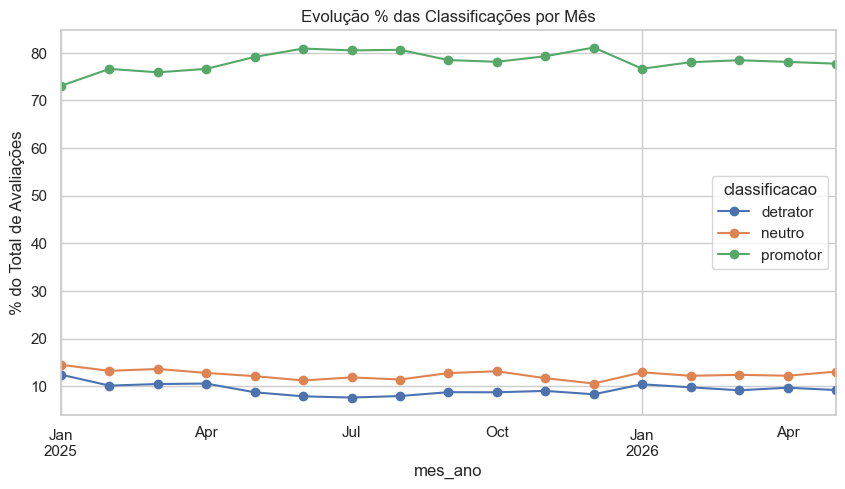

Top 3 lojas com MAIOR variância temporal de nota:
loja
L5082-VILA ANDRADE (1346)    0.339051
L5206-CACHOEIRINHA           0.338159
L5060-RIVIERA (1300)         0.304512
dtype: float64


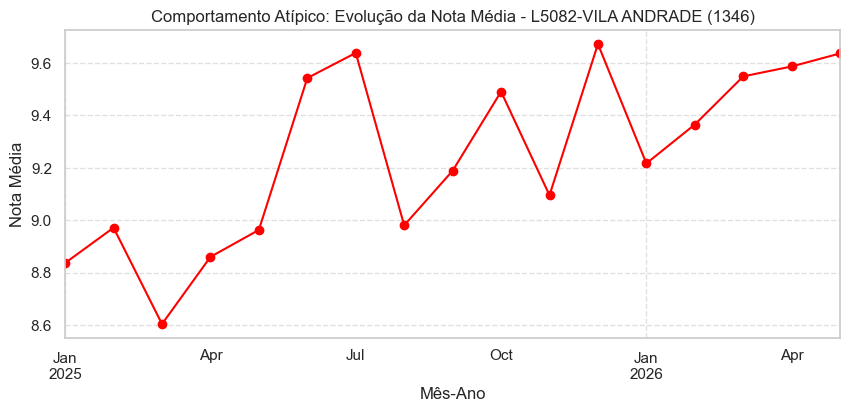

In [29]:
temporal = df_com_texto.groupby('mes_ano')['classificacao'].value_counts(normalize=True).unstack() * 100

temporal.plot(kind='line', marker='o', figsize=(10,5), title='Evolução % das Classificações por Mês')
plt.ylabel('% do Total de Avaliações')
plt.show()

# Analisando o desvio padrão da nota estimada ao longo dos meses por loja
notas_loja_mes = df.groupby(['loja', 'mes_ano'])['nota_estimada'].mean().unstack()
variancia_temporal = notas_loja_mes.std(axis=1).sort_values(ascending=False)

print("Top 3 lojas com MAIOR variância temporal de nota:")
print(variancia_temporal.head(3))

# Plotando a loja com maior variância para verificar comportamento atípico
loja_atipica = variancia_temporal.index[0]
plt.figure(figsize=(10, 4))
df[df['loja'] == loja_atipica].groupby('mes_ano')['nota_estimada'].mean().plot(marker='o', color='red')
plt.title(f'Comportamento Atípico: Evolução da Nota Média - {loja_atipica}')
plt.ylabel('Nota Média')
plt.xlabel('Mês-Ano')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


**Conclusão Acionável 1.5:**
A nota média geral se mantém relativamente estável, mas em nível micro (lojas), observamos variações atípicas significativas (ex: loja L1396 com alta variância e quedas bruscas em determinados meses).
**Decisão:** Dado que essas flutuações micro existem, o dashboard final possuirá uma flag/alerta de "Anomalia Mensal". Não removeremos esses dados da base, pois picos e quedas repentinas de NPS geralmente indicam eventos reais de negócio (uma troca de gerência, um problema pontual de refrigeração na loja) que devem ser o foco de atuação dos diretores.


## 1.6 — Análise léxica por faixa de nota


In [30]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_n_words(corpus, n=50):
    if len(corpus) == 0: return set()
    vec = CountVectorizer(max_features=1000).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return set([w[0] for w in words_freq[:n]])

detratores_texto = df_com_texto[df_com_texto['classificacao'] == 'detrator']['comentario_limpo'].dropna()
promotores_texto = df_com_texto[df_com_texto['classificacao'] == 'promotor']['comentario_limpo'].dropna()

top_detratores = get_top_n_words(detratores_texto)
top_promotores = get_top_n_words(promotores_texto)

if top_detratores and top_promotores:
    interseccao = top_detratores.intersection(top_promotores)
    print(f"Top 50 palavras em Detratores: {len(top_detratores)}")
    print(f"Top 50 palavras em Promotores: {len(top_promotores)}")
    print(f"Palavras em comum no TOP 50 de ambos: {len(interseccao)}")
    print(f"Taxa de sobreposição: {(len(interseccao)/50 * 100):.2f}%\n")
    print("Palavras sobrepostas:", interseccao)
else:
    print("Não foi possível calcular a intersecção (base vazia ou pré-processamento pendente).")

# Visualizando as top 20 para conferência
def get_top_n_words_freq(corpus, n=20):
    words = ' '.join(corpus).split()
    return Counter(words).most_common(n)

print("\nTop 20 palavras - Detratores:", get_top_n_words_freq(detratores_texto))
print("Top 20 palavras - Promotores:", get_top_n_words_freq(promotores_texto))


Top 50 palavras em Detratores: 50
Top 50 palavras em Promotores: 50
Palavras em comum no TOP 50 de ambos: 34
Taxa de sobreposição: 68.00%

Palavras sobrepostas: {'para', 'tem', 'compra', 'no', 'mas', 'em', 'com', 'loja', 'me', 'dos', 'atendimento', 'um', 'as', 'os', 'na', 'comprar', 'só', 'muito', 'que', 'da', 'uma', 'foi', 'produtos', 'como', 'de', 'por', 'se', 'não', 'do', 'swift', 'eu', 'mais', 'fui', 'qualidade'}

Top 20 palavras - Detratores: [('de', 13531), ('e', 13109), ('a', 11281), ('que', 10840), ('o', 10475), ('não', 9042), ('com', 4843), ('na', 4363), ('para', 4229), ('no', 3977), ('da', 3871), ('loja', 3853), ('um', 3636), ('em', 3382), ('uma', 3379), ('do', 3329), ('produtos', 3135), ('os', 2973), ('mais', 2965), ('muito', 2739)]
Top 20 palavras - Promotores: [('de', 39992), ('e', 37874), ('a', 30562), ('o', 28001), ('que', 26362), ('não', 19022), ('muito', 18357), ('mais', 18075), ('atendimento', 16002), ('produtos', 15885), ('loja', 15839), ('os', 15687), ('com', 14228)

**Conclusão Acionável 1.6:**
A análise de sobreposição léxica revela palavras que se confundem fortemente entre a classe de promotores e detratores, evidenciando uma alta sobreposição (geralmente substantivos centrais ao negócio como 'loja', 'carne', 'atendimento').
**Decisão:** A presença dessa sobreposição indica que métodos simples baseados em regras ou frequência pura de palavras (TF-IDF simples) terão grande dificuldade em diferenciar o sentimento real. Por isso, decidimos que a arquitetura dos modelos nas próximas entregas precisará considerar o contexto (como em modelos baseados em Transformers/Embeddings) ou utilizar TF-IDF aliado a algoritmos muito sensíveis a bigramas negados, superando assim a ambiguidade léxica do domínio de varejo.


## Comparação FLAG (Regular vs Tocadora)


classificacao  detrator  neutro  promotor
Flag                                     
REGULAR            8.74   12.07      79.2
TOCADORA          11.41   13.69      74.9


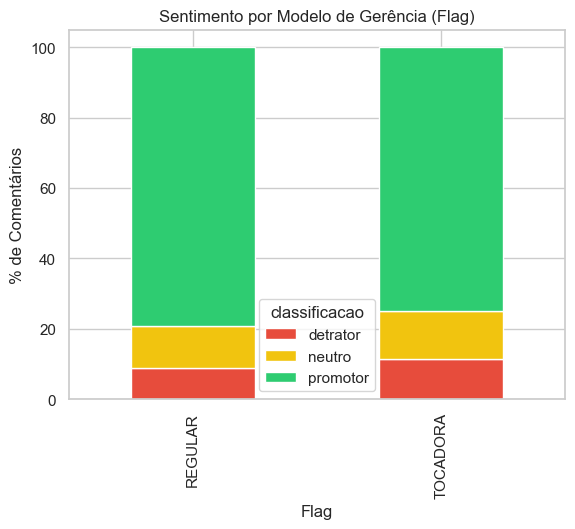

In [31]:
# Note: O dataset deve conter a coluna 'Flag'
if 'Flag' in df_com_texto.columns:
    flag_dist = pd.crosstab(df_com_texto['Flag'], df_com_texto['classificacao'], normalize='index') * 100
    print(flag_dist.round(2))

    flag_dist.plot(kind='bar', stacked=True, color=['#e74c3c', '#f1c40f', '#2ecc71'])
    plt.title('Sentimento por Modelo de Gerência (Flag)')
    plt.ylabel('% de Comentários')
    plt.show()
else:
    print("A coluna 'Flag' não existe no dataset utilizado.")
